# Los algoritmos compiten: una instancia, paso a paso

Para *ver* en qué se diferencian los algoritmos, los ponemos a competir en una sola
instancia chica y trazamos qué hace cada uno: qué pool elige en cada paso, qué
resultado obtiene, a quién limpia y cuánta utilidad acumula.

Cuatro competidores: el **óptimo** (programación dinámica, el techo), el **greedy
miope** (elige el pool de mayor recompensa inmediata), el **greedy con conteo**
(igual de miope al elegir, pero con el posterior exacto de toda la historia) y el
**greedy con lookahead** (anticipa el primer paso en vez de ser puramente miope).

La instancia está elegida a propósito: es de las que hacen que el miope y el óptimo
**diverjan ya en la primera jugada**, que es donde vive la mayor parte del hueco.


In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import numpy as np, matplotlib.pyplot as plt
from augmented.solver import solve_optimal_dapts
from augmented.simulator import apply_dapts
from augmented.greedy import (_myopic_best_pool, greedy_myopic_simulate,
                              greedy_myopic_counting_simulate, greedy_lookahead_simulate)
from augmented.core import mask_str, indices_from_mask, popcount, test_result
from augmented.baselines import u_max

# La instancia didáctica (n=5, B=2, G=3)
p = [0.393, 0.104, 0.418, 0.579, 0.589]
u = [1.0, 3.0, 2.0, 3.0, 3.0]
n, B, G = 5, 2, 3
opt_val, pol = solve_optimal_dapts(p, u, B, G)

print('persona :   0      1      2      3      4')
print('p (riesgo):', '  '.join(f'{x:.3f}' for x in p))
print('u (valor) :', '  '.join(f'{x:.1f}  ' for x in u))
print(f'\nB={B} tests, pools de hasta G={G}.  Techo de información U_max={u_max(p,u):.3f}')

# runners uniformes: cada uno toma z y devuelve (history, cleared_mask, utility)
runners = {
    'Óptimo (DP)':      lambda z: apply_dapts(pol, z, n, u),
    'Greedy miope':     lambda z: greedy_myopic_simulate(p, u, B, G, z),
    'Greedy counting':  lambda z: greedy_myopic_counting_simulate(p, u, B, G, z),
    'Greedy lookahead': lambda z: greedy_lookahead_simulate(p, u, B, G, z),
}

persona :   0      1      2      3      4
p (riesgo): 0.393  0.104  0.418  0.579  0.589
u (valor) : 1.0    3.0    2.0    3.0    3.0  

B=2 tests, pools de hasta G=3.  Techo de información U_max=6.955


## 1. La divergencia en la primera jugada

El greedy miope puntúa cada pool por su recompensa inmediata,
$\text{Score}(t)=\prod_{i\in t}(1-p_i)\cdot\sum_{i\in t}u_i$ = (probabilidad de que
salga limpio) × (utilidad que cosecharía). Veamos qué elige, y compáralo con el
óptimo.

In [2]:
def score(t):
    idx = indices_from_mask(t, n)
    prob = np.prod([1 - p[i] for i in idx])
    gain = sum(u[i] for i in idx)
    return prob * gain

from augmented.core import all_pools
cands = sorted([t for t in all_pools(n, G, include_empty=False)], key=score, reverse=True)
print('Top pools por Score miope (prob_limpio × utilidad):')
for t in cands[:5]:
    idx = indices_from_mask(t, n)
    print(f'  {mask_str(t,n):8s}  prob={np.prod([1-p[i] for i in idx]):.3f}  '
          f'u={sum(u[i] for i in idx):.0f}  Score={score(t):.3f}')

myo_first = _myopic_best_pool(p, u, G, n, 0)
opt_first = pol.choose(1, ())
print(f'\n  El MIOPE elige   {mask_str(myo_first,n)}  (el de mayor Score)')
print(f'  El ÓPTIMO elige  {mask_str(opt_first,n)}  (mira más allá del paso inmediato)')

Top pools por Score miope (prob_limpio × utilidad):
  {1}       prob=0.896  u=3  Score=2.688
  {1,2}     prob=0.521  u=5  Score=2.607
  {1,3}     prob=0.377  u=6  Score=2.263
  {1,4}     prob=0.368  u=6  Score=2.210
  {0,1}     prob=0.544  u=4  Score=2.175

  El MIOPE elige   {1}  (el de mayor Score)
  El ÓPTIMO elige  {1,2}  (mira más allá del paso inmediato)


El miope elige la persona 1 sola: es la más segura (riesgo 0.104) y vale 3, así
que su Score gana por un pelo. El óptimo, en cambio, mete a la persona 1 **junto
con la 2**: arriesga un poco más, pero si el pool sale limpio cosecha 3+2 de un solo
test, y además deja mejor preparado el segundo. El miope es demasiado cauteloso;
limpia de a uno.

## 2. El trazo cuando NADIE está infectado

El caso más claro. Si nadie está infectado, todo pool sale limpio (r=0). Veamos qué
limpia cada algoritmo en sus dos tests.

In [3]:
def traza(nombre, z):
    history, cleared, util = runners[nombre](z)
    filas, acc_mask = [], 0
    for k, (pool, r) in enumerate(history, 1):
        limpio = (r == 0)
        if limpio: acc_mask |= pool
        cleared_u = sum(u[i] for i in indices_from_mask(acc_mask, n))
        filas.append((k, mask_str(pool, n), r, 'sí' if limpio else 'no', cleared_u))
    return filas, util

def mostrar(z):
    print(f'Perfil real z: infectados = {indices_from_mask(z,n) or "(nadie)"}\n')
    for nombre in runners:
        filas, util = traza(nombre, z)
        print(f'{nombre}  ->  utilidad final = {util:.0f}')
        print(f'   {"paso":>4} {"pool":>8} {"r":>3} {"limpio":>7} {"util.acum":>9}')
        for (k, pl, r, lim, cu) in filas:
            print(f'   {k:>4} {pl:>8} {r:>3} {lim:>7} {cu:>9.0f}')
        print()

mostrar(0)   # z=0: nadie infectado

Perfil real z: infectados = (nadie)

Óptimo (DP)  ->  utilidad final = 8
   paso     pool   r  limpio util.acum
      1    {1,2}   0      sí         5
      2      {3}   0      sí         8

Greedy miope  ->  utilidad final = 6
   paso     pool   r  limpio util.acum
      1      {1}   0      sí         3
      2      {3}   0      sí         6

Greedy counting  ->  utilidad final = 6
   paso     pool   r  limpio util.acum
      1      {1}   0      sí         3
      2      {3}   0      sí         6

Greedy lookahead  ->  utilidad final = 8
   paso     pool   r  limpio util.acum
      1    {1,2}   0      sí         5
      2      {3}   0      sí         8



Aquí se ve el comportamiento. El óptimo agrupa para limpiar a 1 y 2 juntos en el
primer test y luego cosecha otra persona de valor 3: termina en 8. El miope limpia
a la persona 1 sola, y aunque el segundo test le va bien, **nunca alcanza a limpiar
a la persona 2**: termina en 6. La cautela del miope le cuesta 2 de utilidad en esta
realización.

## 3. El trazo cuando alguien SÍ está infectado

Para ver cómo reaccionan, tomamos una realización con un infectado y la trazamos
igual.

In [4]:
# elegimos un z con un infectado donde el resultado sea ilustrativo
from augmented.core import mask_from_indices
z_inf = mask_from_indices([3])   # la persona 3 (alto riesgo, alto valor) infectada
mostrar(z_inf)

Perfil real z: infectados = [3]

Óptimo (DP)  ->  utilidad final = 5
   paso     pool   r  limpio util.acum
      1    {1,2}   0      sí         5
      2      {3}   1      no         5

Greedy miope  ->  utilidad final = 3
   paso     pool   r  limpio util.acum
      1      {1}   0      sí         3
      2      {3}   1      no         3

Greedy counting  ->  utilidad final = 3
   paso     pool   r  limpio util.acum
      1      {1}   0      sí         3
      2      {3}   1      no         3

Greedy lookahead  ->  utilidad final = 5
   paso     pool   r  limpio util.acum
      1    {1,2}   0      sí         5
      2      {3}   1      no         5



Cuando el pool del óptimo toca a un infectado, el test ya no sale limpio (r>0) y
nadie de ese pool se cobra; cada algoritmo reacomoda según su creencia actualizada.
El conteo, además, usa el valor exacto de r para afinar el posterior de cara al
segundo test.

## 4. El veredicto: utilidad esperada sobre TODAS las realizaciones

Un perfil suelto ilustra, pero la comparación justa promedia sobre los $2^n$
escenarios de infección, pesados por su probabilidad. Esa es la utilidad esperada
de cada algoritmo.

Utilidad esperada (promedio sobre los 32 escenarios):
   Óptimo (DP)        4.4445   (+0.00% vs óptimo)
   Greedy miope       3.9510   (+11.10% vs óptimo)
   Greedy counting    3.9510   (+11.10% vs óptimo)
   Greedy lookahead   4.4445   (+0.00% vs óptimo)
   U_max (techo info) 6.9550


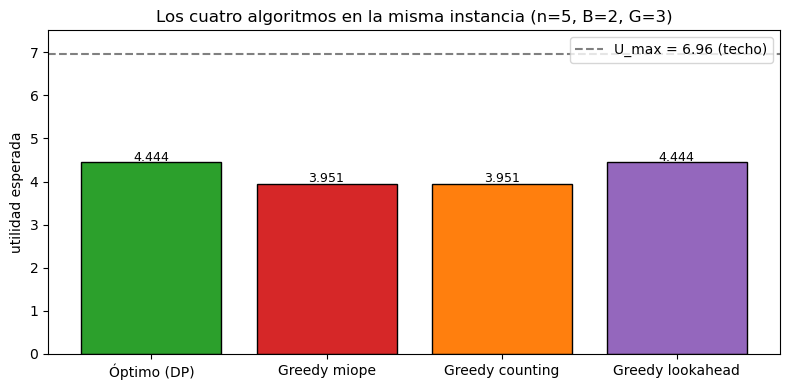

In [5]:
def eu(nombre):
    q = [1 - x for x in p]; tot = 0.0
    for z in range(1 << n):
        w = 1.0
        for i in range(n): w *= p[i] if (z >> i & 1) else q[i]
        if w == 0: continue
        _, _, util = runners[nombre](z)
        tot += w * util
    return tot

vals = {nombre: eu(nombre) for nombre in runners}
umax = u_max(p, u)
print('Utilidad esperada (promedio sobre los 32 escenarios):')
for nombre, v in vals.items():
    print(f'   {nombre:18s} {v:.4f}   ({(opt_val-v)/opt_val*100:+.2f}% vs óptimo)')
print(f'   {"U_max (techo info)":18s} {umax:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
nombres = list(vals.keys())
colores = ['tab:green', 'tab:red', 'tab:orange', 'tab:purple']
ax.bar(nombres, [vals[k] for k in nombres], color=colores, edgecolor='k')
ax.axhline(umax, ls='--', color='0.5', label=f'U_max = {umax:.2f} (techo)')
for i, k in enumerate(nombres):
    ax.text(i, vals[k] + 0.03, f'{vals[k]:.3f}', ha='center', fontsize=9)
ax.set_ylabel('utilidad esperada'); ax.set_ylim(0, umax * 1.08)
ax.set_title('Los cuatro algoritmos en la misma instancia (n=5, B=2, G=3)')
ax.legend(); plt.tight_layout(); plt.show()

## La lección

El orden en esta instancia es **óptimo = lookahead (4.44) > miope = counting (3.95)**,
y los dos empates dicen tanto como la brecha.

El **miope** pierde ~11% por impaciencia: maximiza la recompensa del próximo test, y
por eso limpia a la persona más segura sola en vez de agrupar y cosechar más. El
**lookahead iguala exactamente al óptimo** aquí, y no es coincidencia: con $B=2$ el
único paso futuro es el último, donde ser miope ya es óptimo, así que anticipar ese
paso equivale a la optimización completa de los dos tests. El **counting empata con
el miope** porque con $B=2$ solo hay un test en la historia al decidir el segundo, y
con un solo test el posterior por conteo coincide con el secuencial; el conteo solo
se despega cuando hay tests que se solapan, es decir $B\ge 3$.

Eso conecta con el otro hallazgo: a $B=3$ el lookahead de un paso ya **no** cierra
todo el hueco, solo ~40%, porque deja dos pasos futuros jugados de forma miope.
Anticipar un paso basta cuando el horizonte es uno; con horizontes más largos hay que
anticipar más. La intuición que queda: la miopía no es "ser tonto", es "ser
impaciente", y cuánto cuesta esa impaciencia depende de cuánto futuro estás
desperdiciando.